In [2]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

In [3]:
data_path = "../data/processed"
df = pd.read_csv(os.path.join(data_path, "college_productionpergame_with_avg_sp_and_av.csv"))
df.head()

,Player,Rate,Draft Team,Round,Pick,Draft Year,Draft College,From,To,G,...,age,dr_av,w_av,Solo/G,Ast/G,Comb/G,TFL/G,Int/G,IntTD/G,PD/G
0,Cam Newton,178.2,CAR,1,1,2011,Auburn,2007,2010,20.0,...,22.0,107.0,115.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Von Miller,NaN,DEN,1,2,2011,Texas A&M,2007,2010,47.0,...,22.0,97.0,105.0,2.212766,1.638298,3.851064,1.074468,NaN,NaN,NaN
2,Marcell Dareus,NaN,BUF,1,3,2011,Alabama,2009,2010,25.0,...,21.0,47.0,56.0,1.560000,1.080000,2.640000,0.800000,NaN,NaN,NaN
3,A.J. Green,NaN,CIN,1,4,2011,Georgia,2008,2010,32.0,...,23.0,71.0,77.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Patrick Peterson,NaN,CRD,1,5,2011,LSU,2008,2010,39.0,...,21.0,95.0,103.0,NaN,NaN,NaN,NaN,0.179487,0.025641,0.0


In [4]:
print("Original shape:", df.shape)

Original shape: (2321, 59)


In [5]:
df["Pos"] = df["Pos"].astype(str).str.strip()

# convert to numeric, coercing errors to NaN
text_cols = ["Player", "Pos", "Team", "Draft Team", "Draft College"]

for col in df.columns:
    if col not in text_cols:
        df[col] = pd.to_numeric(df[col], errors = "coerce")

df = df.dropna(subset=["dr_av"]).copy()

print("Shape after dropping missing dr_av:", df.shape)

Shape after dropping missing dr_av: (2016, 59)


In [6]:
df = df[~df["Pos"].isin(["FB", "LS"])].copy()

In [7]:
def map_position(pos):
    if pos == "QB":
        return "QB"
    elif pos in ["RB", "WR", "TE"]:
        return "Skill"
    elif pos in ["OL", "T", "OT", "G", "OG", "C"]:
        return "OL"
    elif pos in ["DL", "DE", "DT", "LB", "OLB", "ILB", "EDGE"]:
        return "Front7"
    elif pos in ["DB", "CB", "S", "FS", "SS"]:
        return "DB"
    else:
        return "Other"

df["PosGroup"] = df["Pos"].apply(map_position)
df = df[df["PosGroup"] != "Other"].copy()

print("\nPosition group counts:")
print(df["PosGroup"].value_counts())



Position group counts:
PosGroup
Front7    645
Skill     590
DB        446
OL        233
QB         91
Name: count, dtype: int64


In [8]:
drop_cols = [
    "Draft Team",
    "Round",
    "Pick",
    "From",
    "To",
    "G",
    "Rate",
    "w_av"
]

df_model = df.drop(columns=drop_cols, errors="ignore").copy()

In [9]:
common_features = [
    "age",
    "avg_team_sp"
]

# QB: keep efficiency + per-game passing volume
qb_features = common_features + [
    "qb_Cmp%",
    "qb_Y/A",
    "qb_AY/A",
    "qb_TD%",
    "qb_Int%",
    "qb_Y/G"
]

# Skill: keep per-game and efficiency rushing/receiving stats
skill_features = common_features + [
    "rb_rush_Y/G",
    "rb_rush_Y/A",
    "rb_rec_Y/G",
    "rb_rec_Y/R",
    "rec_Y/G",
    "rec_Y/R"
]

# OL: no strong OL production stats in this csv, so just keep common features
ol_features = common_features.copy()

# Front7: keep disruption + activity per game
front7_features = common_features + [
    "Sk/G",
    "TFL/G",
    "Comb/G"
]

# DB:keep tackling activity + ball production + coverage disruption
db_features = common_features + [
    "Comb/G",
    "Int/G",
    "PD/G"
]

group_feature_map = {
    "QB": qb_features,
    "Skill": skill_features,
    "OL": ol_features,
    "Front7": front7_features,
    "DB": db_features
}

In [10]:
group_dfs = {}

for group_name, feature_list in group_feature_map.items():
    group_df = df_model[df_model["PosGroup"] == group_name].copy()

    keep_cols = [col for col in feature_list if col in group_df.columns]
    keep_cols.append("dr_av")

    group_df = group_df[keep_cols].copy()

    numeric_cols = group_df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_feature_cols = [col for col in numeric_cols if col != "dr_av"]

    group_df[numeric_feature_cols] = group_df[numeric_feature_cols].fillna(0)

    group_dfs[group_name] = group_df

In [11]:
for group_name, group_df in group_dfs.items():
    print(group_name)
    print(group_df.columns.tolist())
    print(group_df.shape)
    print()

QB
['age', 'avg_team_sp', 'qb_Cmp%', 'qb_Y/A', 'qb_AY/A', 'qb_TD%', 'qb_Int%', 'qb_Y/G', 'dr_av']
(91, 9)

Skill
['age', 'avg_team_sp', 'rb_rush_Y/G', 'rb_rush_Y/A', 'rb_rec_Y/G', 'rb_rec_Y/R', 'rec_Y/G', 'rec_Y/R', 'dr_av']
(590, 9)

OL
['age', 'avg_team_sp', 'dr_av']
(233, 3)

Front7
['age', 'avg_team_sp', 'Sk/G', 'TFL/G', 'Comb/G', 'dr_av']
(645, 6)

DB
['age', 'avg_team_sp', 'Comb/G', 'Int/G', 'PD/G', 'dr_av']
(446, 6)



In [12]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [13]:
model_dict = {
    "Dummy": DummyRegressor(strategy="mean"),

    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha = 0.01, max_iter = 10000))
    ]),

    "ElasticNet": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha = 0.01, l1_ratio = 0.5, max_iter = 10000))
    ]),

    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators = 200,
            random_state = 42
        ))
    ]),

    "ExtraTrees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(
            n_estimators = 200,
            random_state = 42
        ))
    ]),

    "HistGB": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingRegressor(
            learning_rate = 0.1,
            max_iter = 200,
            random_state = 42
        ))
    ]),

    "AdaBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", AdaBoostRegressor(
            n_estimators = 200,
            random_state = 42
        ))
    ]),

    "SVR": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", SVR(C = 1.0, epsilon = 0.1, kernel = "rbf"))
    ]),

    "KNN": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors = 5))
    ]),

    "MLP": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes = (32,),
            alpha = 0.001,
            max_iter = 5000,
            random_state = 42
        ))
    ])
}

In [14]:
output_dir = "../data/processed_2"
os.makedirs(output_dir, exist_ok=True)

results = []
trained_models = {}
split_data = {}

for group_name, group_df in group_dfs.items():

    X = group_df.drop(columns = ["dr_av"]).copy()
    y = group_df["dr_av"].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size = 0.2,
        random_state = 42
    )

    split_data[group_name] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    trained_models[group_name] = {}

    for model_name, model in model_dict.items():

        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)

        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

        results.append({
            "group": group_name,
            "model": model_name,
            "train_r2": train_r2,
            "test_r2": test_r2,
            "train_rmse": train_rmse,
            "test_rmse": test_rmse,
            "n_train": len(X_train),
            "n_test": len(X_test),
            "n_features": X.shape[1]
        })

        trained_models[group_name][model_name] = model

results_df = pd.DataFrame(results)

model_results = {}

for model_name in results_df["model"].unique():

    model_df = results_df[results_df["model"] == model_name].copy()

    model_results[f"{model_name}_df"] = model_df

    model_df.to_csv(
        os.path.join(output_dir, f"{model_name}_results.csv"),
        index = False
    )

results_df.to_csv(
    os.path.join(output_dir, "all_model_results.csv"),
    index = False
)

summary_df = (
    results_df
    .sort_values(["group", "test_r2"], ascending=[True, False])
    .copy()
)

c:\Users\Aoi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Aoi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Aoi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Aoi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [15]:
print("\nResults summary:")
print(summary_df)


Results summary:
     group         model  train_r2   test_r2  train_rmse  test_rmse  n_train  \
45      DB         Ridge  0.057798  0.034228   11.179706  16.819394      356   
47      DB    ElasticNet  0.057796  0.034109   11.179719  16.820428      356   
46      DB         Lasso  0.057796  0.034053   11.179718  16.820918      356   
44      DB         Dummy  0.000000 -0.002734   11.517506  17.138227      356   
51      DB      AdaBoost  0.181283 -0.026343   10.421383  17.338811      356   
54      DB           MLP  0.230174 -0.029471   10.105430  17.365211      356   
52      DB           SVR -0.005283 -0.045649   11.547891  17.501128      356   
48      DB  RandomForest  0.846819 -0.056886    4.507768  17.594914      356   
49      DB    ExtraTrees  1.000000 -0.101438    0.000000  17.961933      356   
50      DB        HistGB  0.786541 -0.119950    5.321273  18.112247      356   
53      DB           KNN  0.233331 -0.120071   10.084686  18.113224      356   
35  Front7         Las

In [16]:
best3_df = (
    results_df
    .sort_values(["group", "test_r2"], ascending=[True, False])
    .groupby("group")
    .head(3)
    .reset_index(drop=True)
)

print("\nBest 3 models per group:")
print(best3_df[[
    "group", "model", "test_r2", "test_rmse",
    "train_r2", "train_rmse"
]].round(4))


Best 3 models per group:
     group       model  test_r2  test_rmse  train_r2  train_rmse
0       DB       Ridge   0.0342    16.8194    0.0578     11.1797
1       DB  ElasticNet   0.0341    16.8204    0.0578     11.1797
2       DB       Lasso   0.0341    16.8209    0.0578     11.1797
3   Front7       Lasso   0.1417    18.1545    0.0965     18.3159
4   Front7       Ridge   0.1416    18.1548    0.0965     18.3158
5   Front7  ElasticNet   0.1416    18.1555    0.0965     18.3159
6       OL       Dummy  -0.0016    19.7975    0.0000     19.3946
7       OL       Lasso  -0.0185    19.9637    0.0528     18.8755
8       OL  ElasticNet  -0.0186    19.9642    0.0528     18.8755
9       QB  ExtraTrees   0.1516    29.1395    1.0000      0.0000
10      QB         KNN   0.1130    29.7954    0.2297     28.9392
11      QB       Dummy  -0.0004    31.6431    0.0000     32.9726
12   Skill         MLP   0.0552    15.0145    0.1692     15.2154
13   Skill  ElasticNet   0.0319    15.1981    0.1213     15.6479

In [17]:
import matplotlib.pyplot as plt
import math

In [18]:
colors = [
    "#6b8fb4",  # muted blue
    "#c48a69",  # muted orange
    "#7aa37a",  # muted green
    "#a57aa5",  # muted purple
    "#c2a76b",  # muted gold
    "#8c8c8c"   # muted gray
]

In [19]:
fig_dir = os.path.join(output_dir, "figures")
os.makedirs(fig_dir, exist_ok = True)

group_order = ["QB", "Skill", "OL", "Front7", "DB"]
group_order = [g for g in group_order if g in results_df["group"].unique()]

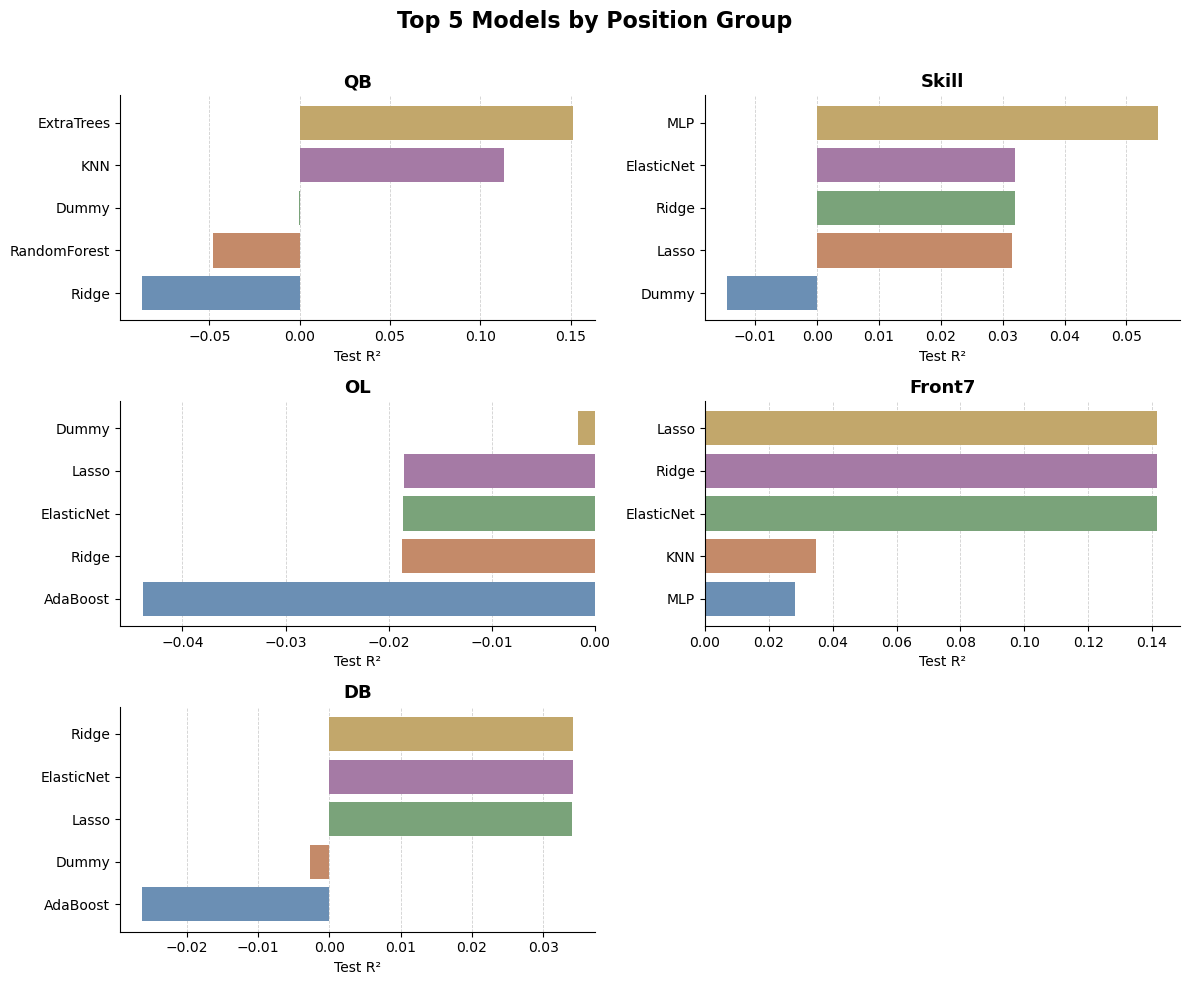

In [20]:
n_groups = len(group_order)
ncols = 2
nrows = math.ceil(n_groups / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize = (12, 10))
axes = axes.flatten()

for i, group_name in enumerate(group_order):
    ax = axes[i]

    temp = (
        results_df[results_df["group"] == group_name]
        .sort_values("test_r2", ascending=False)
        .head(5)
        .copy()
    )

    temp = temp.sort_values("test_r2", ascending=True)

    ax.barh(
        temp["model"],
        temp["test_r2"],
        color=colors[:len(temp)]
    )

    ax.set_title(group_name, fontsize = 13, fontweight="bold")
    ax.set_xlabel("Test R²", fontsize = 10)
    ax.set_ylabel("")

    ax.xaxis.grid(True, linestyle="--", linewidth = 0.6, alpha = 0.6)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Top 5 Models by Position Group", fontsize = 16, fontweight="bold")
plt.tight_layout(rect = [0, 0, 1, 0.97])

plt.savefig(os.path.join(fig_dir, "top5_models_per_group.png"), dpi = 300)
plt.show()

In [21]:
comparison_rows = []

for group_name in group_order:
    group_results = results_df[results_df["group"] == group_name].copy()

    dummy_row = group_results[group_results["model"] == "Dummy"].iloc[0]
    best_row = group_results.sort_values("test_r2", ascending=False).iloc[0]

    comparison_rows.append({
        "group": group_name,
        "best_model": best_row["model"],
        "best_model_test_r2": best_row["test_r2"],
        "dummy_test_r2": dummy_row["test_r2"]
    })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df)

    group  best_model  best_model_test_r2  dummy_test_r2
0      QB  ExtraTrees            0.151607      -0.000444
1   Skill         MLP            0.055173      -0.014635
2      OL       Dummy           -0.001622      -0.001622
3  Front7       Lasso            0.141666      -0.000090
4      DB       Ridge            0.034228      -0.002734


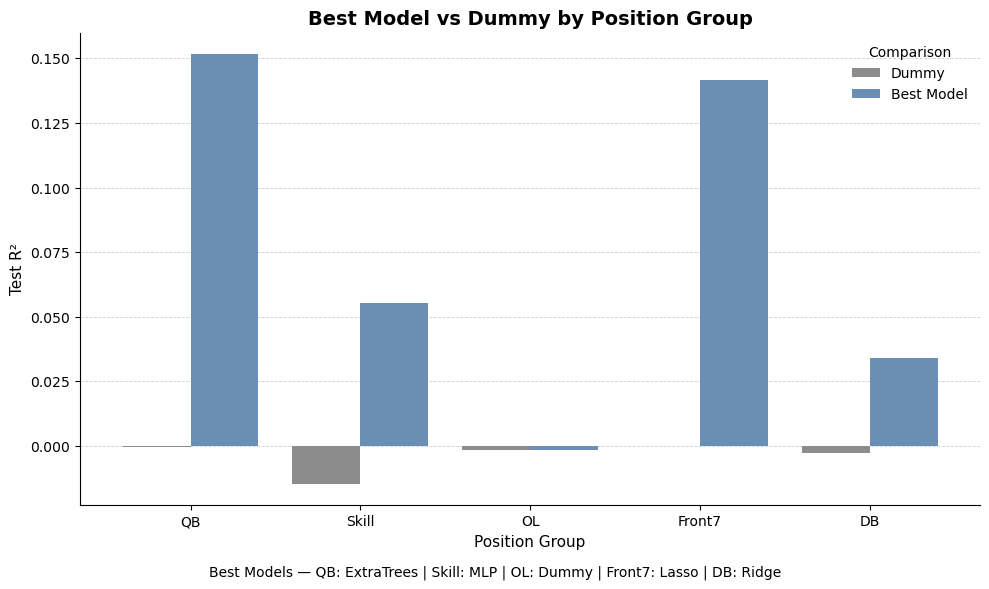

In [22]:
plot_df = comparison_df.set_index("group")[["dummy_test_r2", "best_model_test_r2"]]

colors = [
    "#8c8c8c",
    "#6b8fb4"
]

fig, ax = plt.subplots(figsize=(10, 6))

plot_df.plot(
    kind = "bar",
    ax = ax,
    color = colors,
    width = 0.8
)

ax.set_title("Best Model vs Dummy by Position Group", fontsize = 14, fontweight = "bold")
ax.set_xlabel("Position Group", fontsize = 11)
ax.set_ylabel("Test R²", fontsize = 11)

ax.tick_params(axis="x", rotation=0)

ax.yaxis.grid(True, linestyle="--", linewidth = 0.6, alpha = 0.6)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    ["Dummy", "Best Model"],
    title="Comparison",
    frameon=False
)

best_model_text = "Best Models — " + " | ".join(
    f"{row.group}: {row.best_model}"
    for row in comparison_df.itertuples()
)

fig.text(
    0.5, 0.05,
    best_model_text,
    ha = "center",
    va = "top",
    fontsize = 10
)

plt.tight_layout(rect = [0, 0.05, 1, 1])
plt.savefig(os.path.join(fig_dir, "best_model_vs_dummy_by_group.png"), dpi = 300)
plt.show()

In [25]:
os.makedirs("../data/round2", exist_ok = True)
best3_df.to_csv("../data/round2/best3_df.csv", index = False)